# Attention ： 注意力机制的构造思路
    Q1：为什么需要QK来构造注意力？单一个矩阵S和价值做点积不行吗？
    Q2：注意力机制本质上是一个权重矩阵加权到被注意的信息中，那为什么是对V作注意而不是对原始的X？或者说怎么说明V的表征比原始的S要好？

    A1: 注意力需要$n\times n$的相关性矩阵来表征token之间的相关性，如果只有一个只用一个矩阵S表征注意力，那它必然是$nxn$的，这就要求网络参数尺寸$W\in R_{m\times n}$(假设输入$X\in R_{n\times m}$)，这样注意力网络的参数量就无法固定，需要随着输入长度的变化而变化；
    A2:

In [3]:
import numpy
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [4]:
class Attention(nn.Module):
    """
        X: (batch_size, seq_len, d_k)
        W: (d_model, d_k)
    """
    def __init__(self, d_model, d_k, dropout=0.1):
        super().__init__()
        self.scale = math.sqrt(d_k)
        self.W_q   = nn.Linear(d_model, d_k)
        self.W_k   = nn.Linear(d_model, d_k)
        self.W_v   = nn.Linear(d_model, d_k)

    def forward(self, X):
        #计算投影
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        #计算相关性分数
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        #计算权重矩阵
        R = torch.softmax(scores, dim=-1)
        return torch.matmul(R, V), R


X.shape = torch.Size([2, 5, 16])
output.shape = torch.Size([2, 5, 8])
R.shape = torch.Size([2, 5, 5])
output = tensor([[[ 3.4154e-02,  3.1024e-02, -1.0256e-01, -2.4520e-01,  1.7537e-01,
           4.7410e-02, -1.6088e-01,  1.1705e-01],
         [ 9.2568e-02,  7.3649e-02,  8.4196e-02,  9.9945e-02, -5.1974e-04,
           2.2497e-01, -1.4507e-01, -9.9411e-02],
         [ 3.0982e-02,  3.6601e-02, -3.5941e-02, -1.4063e-01,  1.9834e-01,
           7.7961e-02, -1.2416e-01,  9.3978e-02],
         [ 3.4903e-02,  3.1139e-02, -4.3317e-02, -1.0185e-01,  2.1930e-01,
           8.2976e-02, -1.0262e-01,  9.8012e-02],
         [ 1.0768e-01,  8.2971e-02,  6.9316e-02,  9.9047e-02, -6.3517e-02,
           2.3904e-01, -1.6471e-01, -1.3015e-01]],

        [[-1.4041e-01, -1.9162e-01, -1.4433e-01, -5.8645e-02,  2.1668e-01,
           5.9213e-01,  6.2294e-01, -3.8495e-01],
         [-1.3605e-01, -2.3302e-01, -1.3331e-01, -1.0657e-01,  2.2899e-01,
           5.7289e-01,  6.4542e-01, -3.7037e-01],
         [-3

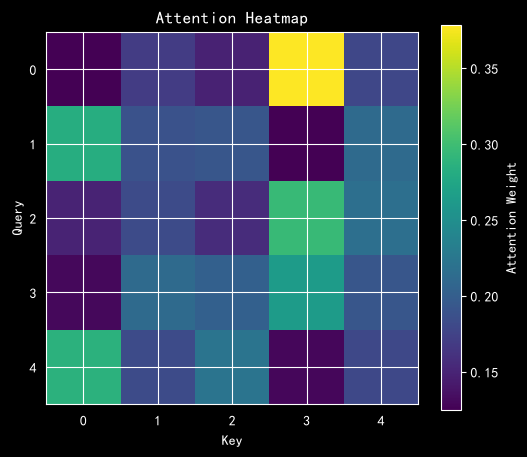

In [5]:
import torch
import matplotlib.pyplot as plt

# 创建 Attention
attention = Attention(
    d_model=16,
    d_k=8
)

# 创建测试输入
X = torch.randn(2, 5, 16)

# 前向计算
output, R = attention(X)

# 打印结果
print("X.shape =", X.shape)
print("output.shape =", output.shape)
print("R.shape =", R.shape)
print("output =", output)

# =========================
# 可视化 Attention 热力图
# =========================

# 取第 0 个 batch
attention_map = R[0].detach().numpy()

plt.figure(figsize=(6, 5))

plt.imshow(
    attention_map,
    cmap="viridis"
)

# 颜色条
plt.colorbar(label="Attention Weight")

# 横纵坐标
plt.xlabel("Key")
plt.ylabel("Query")

# 标题
plt.title("Attention Heatmap")

# token 位置
plt.xticks(range(5))
plt.yticks(range(5))

plt.show()